In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
#X=pd.read_csv('nifty.csv')
#len(X)

In [3]:
def data1():
    X=pd.read_csv('tempcnn.csv')
    X = X.iloc[20:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [4]:
X=data1()

In [5]:
print(len(X))

2870


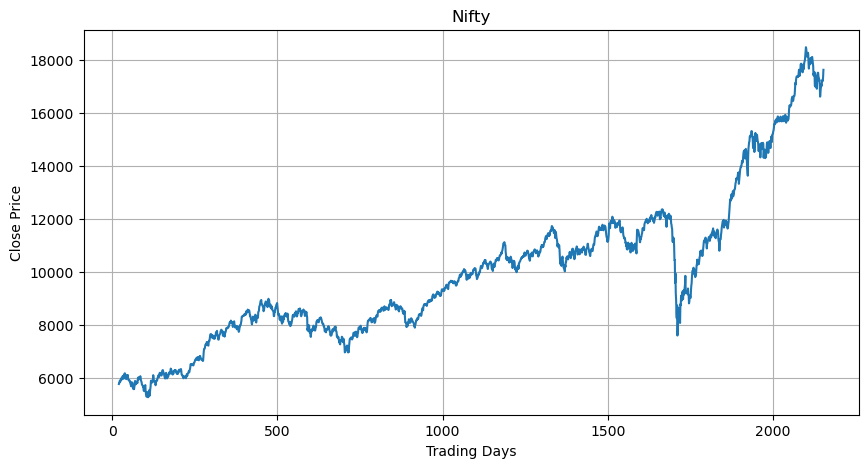

In [7]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure()
ax=X.loc[1:2153,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [8]:
X.head()

,Unnamed: 0,date,Close,High,Low,Open,Volume,weekday,month,p_co,...,BBP_20_2.0,ATRr_14,Target,cnnstate,state2d,cashopen,cash,action,diff,quantity
20,20,2013-04-18,5783.100098,5794.350098,5681.850098,5682.700195,149900.0,0.75,4,0.116719,...,0.823073,0.044696,0,0.0,3.0,0.0,0.0,,,
21,21,2013-04-22,5834.399902,5844.850098,5789.799805,5789.850098,135100.0,0.00,4,0.149119,...,0.860490,0.041362,1,1.0,4.0,0.0,0.0,,,
22,22,2013-04-23,5836.899902,5844.299805,5791.549805,5843.100098,132200.0,0.25,4,0.328945,...,0.817709,0.036904,0,0.0,3.0,0.0,0.0,,,
23,23,2013-04-25,5916.299805,5924.600098,5853.299805,5856.100098,199600.0,0.75,4,-0.279732,...,0.862009,0.038064,2,2.0,2.0,0.0,0.0,,,
24,24,2013-04-26,5871.450195,5907.049805,5860.500000,5899.750000,141300.0,1.00,4,0.104742,...,0.772120,0.034307,0,0.0,3.0,0.0,0.0,,,


In [9]:
X['state2d'].value_counts()

state2d
5.0    896
3.0    772
2.0    428
0.0    366
4.0    285
1.0    123
Name: count, dtype: int64

In [10]:
#X.head()

In [11]:
def getState(t):
    t = int(t)
    return(X['state2d'][t])  

In [12]:
class Agent:
    def __init__(self):
        self.epsilon = 1.0
        self.gamma = 0.618
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.Q = np.matrix(np.zeros([6,3]))
        self.learning_rate=0.03
        
    def getAction(self,state):
        state = int(state)
        a=[1,0,2]
        if np.random.rand() <= self.epsilon:
            return random.choice(a)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [13]:
episode_count=100
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=20
    data_length=2153
    state = getState(data_length_start)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    #X.loc[2,'cashopen']=margin 
    X.loc[2, 'cashopen'] = float(margin)
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=float(margin)
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
            
       
        elif action == 2:
            X.loc[t,'cashopen']=float(margin) 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
           
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=int(getState(t+1))
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n",t)
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
        if (agent.epsilon > agent.epsilon_min) and e>1:
                       agent.epsilon *= agent.epsilon_decay
                       
    
    m3=roi
    if m3>m2:
        m1=e
        m2=m3
    #To save model  
    if e%20==0:
        np.save('rl/Qtable'+ str(e)+str('.npy'), agent.Q)
        np.save('rl/epsilon'+ str(e)+str('.npy'), agent.epsilon)
        np.save('rl/gamma'+ str(e)+str('.npy'), agent.gamma)
        np.save('rl/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
        X.to_csv('csv1/AfterTrain'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

Episod 1/100

***********************
 2152
Profit is  -26481.58817400017
Initial Capital is  56827.001950000005
Current Capital is  30345.413775999834
%ROI is  -46.60036121085598
% Buy and Hold= 205.38388766785891
count 1428
qtable [[0.00307444 0.00421056 0.00601127]
 [0.00148487 0.00348083 0.00455472]
 [0.00328615 0.00563368 0.0062925 ]
 [0.00387216 0.00649652 0.00785126]
 [0.00293123 0.00555586 0.00512123]
 [0.00371215 0.00634283 0.00681052]]
epsilon 1.0
--------------------------------
Episod 2/100

***********************
 2152
Profit is  212126.8839599996
Initial Capital is  56827.001950000005
Current Capital is  268953.8859099996
%ROI is  373.2853690691658
% Buy and Hold= 205.38388766785891
count 2062
qtable [[0.00340432 0.00572297 0.01181117]
 [0.00157428 0.00348083 0.00871181]
 [0.0036082  0.00582436 0.01008981]
 [0.00431889 0.00665243 0.00925512]
 [0.00350387 0.00881737 0.005852  ]
 [0.00392859 0.0064162  0.00938836]]
epsilon 0.00998645168764533
------------------------------

In [14]:
agent.Q

matrix([[0.00578653, 0.00799583, 0.01197294],
        [0.00450093, 0.0058284 , 0.00921189],
        [0.00558602, 0.00810113, 0.01023943],
        [0.00566454, 0.00775772, 0.00934325],
        [0.00552883, 0.00891819, 0.00699758],
        [0.00580025, 0.006935  , 0.00948274]])

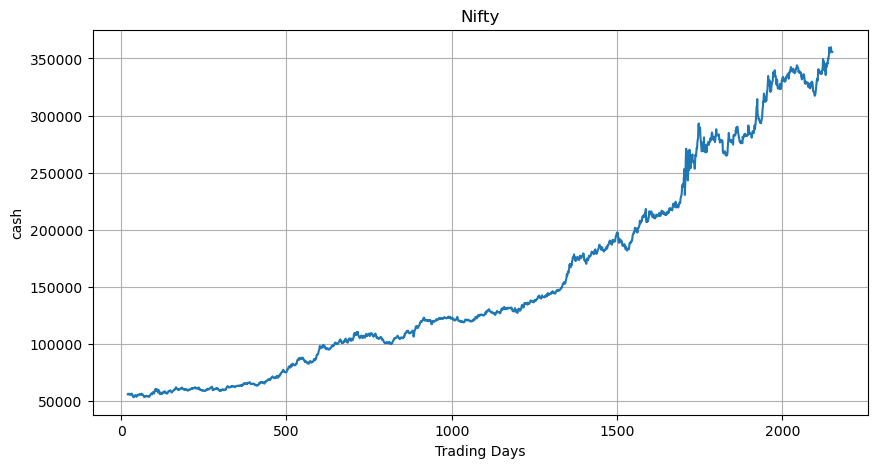

In [15]:
%matplotlib inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-2,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()